In [36]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:

# Load dataset directly from Downloads fold
df = pd.read_csv(r'C:\Users\HomePC\Downloads\car data.csv')



In [38]:

# Check shape (rows, columns) and basic info
df.head()
df.info()
df.describe()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


(301, 9)

## Data Cleaning

In [39]:
#checking null values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

### No missing values

In [40]:
# checking for duplicates
df.duplicated().sum()

np.int64(2)

In [41]:
# Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

In [42]:
# Verify duplicates are removed
df.duplicated().sum()

np.int64(0)

In [43]:
# Print unique values for all text (categorical) columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

Car_Name: ['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Dream Yuga '
 'Bajaj Avenger Street 220' 'H

## Feature Engineering

In [44]:
# Create Car_Age feature
df['Car_Age'] = 2026 - df['Year']

# Drop original Year and high-cardinality Car_Name
df = df.drop(columns=['Year', 'Car_Name'])

In [45]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


## 0ne-Hot Encoding.

In [46]:

# Convert text categories into numeric flags
df = pd.get_dummies(df, drop_first=True, dtype=int)

# Separate features and target label
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [47]:

X.head()

,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000,0,12,0,1,0,1
1,9.54,43000,0,13,1,0,0,1
2,9.85,6900,0,9,0,1,0,1
3,4.15,5200,0,15,0,1,0,1
4,6.87,42450,0,12,1,0,0,1


## Correlation Heatmap

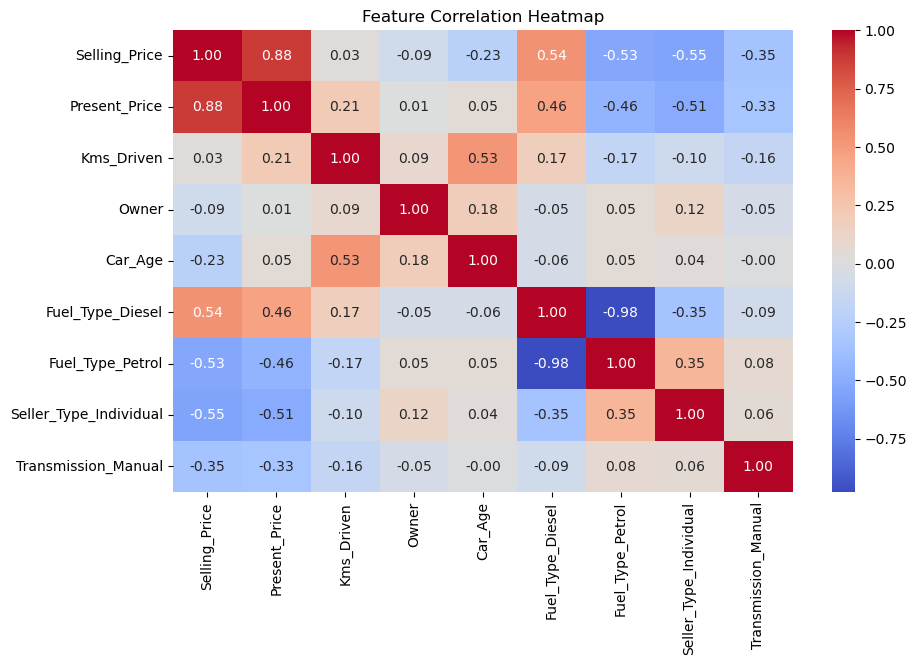

In [48]:
# Calculate correlation matrix using numeric columns only
corr = df.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## Model Trainning

In [49]:
# Split features and target into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
# Initialize and train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
# Initialize and train Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Evaluation

In [52]:
# Predictions
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)

In [53]:
# Linear Regression Metrics
print("Linear Regression:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("R2:", r2_score(y_test, lr_preds))

Linear Regression:
RMSE: 2.524035054594782
MAE: 1.4728924140033008
R2: 0.7528154215832913


In [54]:
#Random Forest Metrics
print("Random Forest:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("R2:", r2_score(y_test, rf_preds))

Random Forest:
RMSE: 3.4154391854733226
MAE: 1.437946666666668
R2: 0.547390441726516


## Actual vs Predicted plot

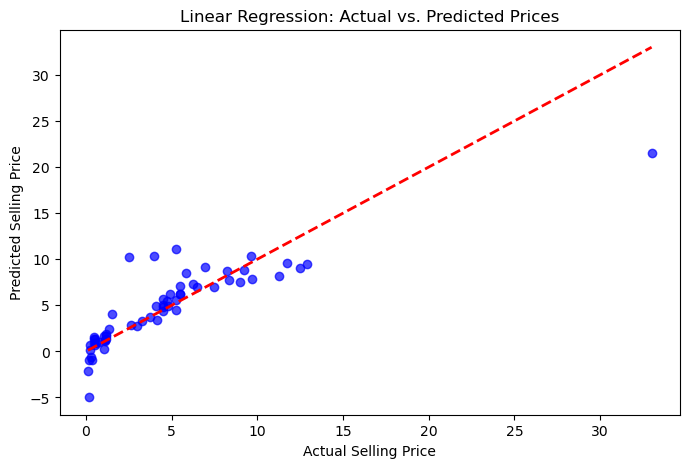

In [55]:
# Actual vs Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_preds, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Linear Regression: Actual vs. Predicted Prices')
plt.show()

## Feature Importance

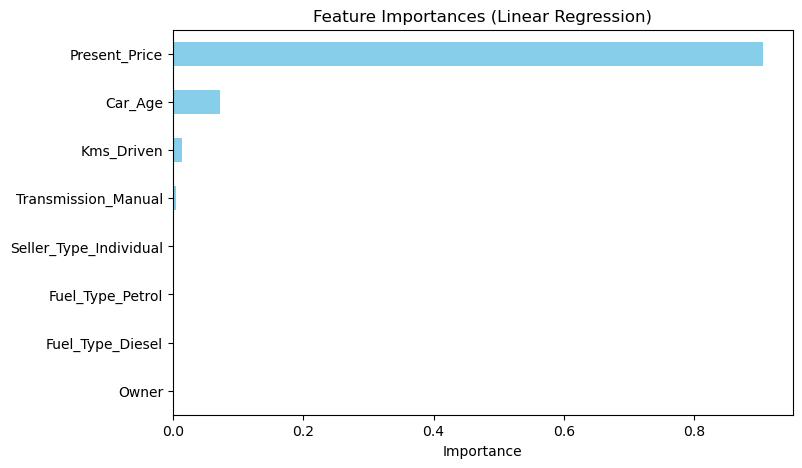

In [56]:
#Top Feature Importances (Linear Regression)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='skyblue', figsize=(8, 5))
plt.title('Feature Importances (Linear Regression)')
plt.xlabel('Importance')
plt.show()